In [4]:
!nvidia-smi

Failed to initialize NVML: Driver/library version mismatch
NVML library version: 535.288


In [7]:
!ls ~/*.sh
!/data/home/syliu/check_slurm_resources.sh

/data/home/syliu/check_resources.sh	   /data/home/syliu/run_notebook.sh
/data/home/syliu/check.sh		   /data/home/syliu/run_processing.sh
/data/home/syliu/check_slurm_resources.sh  /data/home/syliu/run_RNSN_single.sh
/data/home/syliu/gpu.sh			   /data/home/syliu/set_proxy.sh
/data/home/syliu/launch_jupyter.sh	   /data/home/syliu/test_proxy2.sh
/data/home/syliu/mihomo_ctl.sh		   /data/home/syliu/test_proxy.sh
/data/home/syliu/proxy_functions.sh	   /data/home/syliu/unset_proxy.sh
/data/home/syliu/qwen-run.sh		   /data/home/syliu/vpn_forward.sh
当前集群节点状态:
HOSTNAMES            CPUS(A/I/O/T)   MEMORY GRES                      STATE     
node1                0/0/96/96       128000 gpu:1                     drained   
node2                16/80/0/96      128000 gpu:2                     mixed     
node3                12/68/0/80      256000 gpu:4                     mixed     
node5                24/56/0/80      256000 gpu:2                     mixed     
node4                0/80/0/80       2

In [5]:
!squeue -u syliu

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON)


In [22]:
import json 
json_path ="/data1/syliu/ixi_mcx_2025/file_dicts.json"
json_content = json.load(open(json_path, "r"))

from collections import namedtuple
def check(json_c):
    length = len(json_c)
    item_keys = json_c[0].keys()
    item_values = json_c[0].values()
    outputs = namedtuple("outputs",("length","keys","values"))
    return outputs(length,item_keys,item_values)

check(json_content)

outputs(length=10328, keys=dict_keys(['image', 'source_image', 'final_tissues']), values=dict_values(['../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX_FT7_p250_t8_results_log.nii.gz', '../IXI_mcx/m2m_IXI012-HH-/pmcx_output/simple/MCX_FT7_p250_t8_results_log.nii.gz', '../IXI_mcx/m2m_IXI012-HH-/final_tissues.nii.gz']))

In [15]:
test_inputs ='../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX_FT7_p250_t8_results_log.nii.gz'
test_inputs2 ='m2m_IXI012-HH-/pmcx_output/full/MCX_FT7_p250_t8_results_log.nii.gz'

def get_meta(filepath):
    subject = filepath.split("/")[-4]
    _,position,p,t= filepath.split("/")[-1].split("_")[:4]
    p = int(p.replace("p",""))
    t = int(t.replace("t",""))
    return subject,position,p,t



print(get_meta(test_inputs))

print(get_meta(test_inputs2))



('m2m_IXI012-HH-', 'FT7', 250, 8)
('m2m_IXI012-HH-', 'FT7', 250, 8)


In [25]:
import json 
json_path ="/data1/syliu/ixi_mcx_2025/file_dicts.json"
json_content = json.load(open(json_path, "r"))

import pandas as pd 
df = []
for item in json_content:
    subject,position,p,t = get_meta(item["image"])
    # print(subject,position,p,t)
    df.append({
        "subject":subject,
        "position":position,
        "p":p,
        "t":t,
        "image":item["image"],
    })
df = pd.DataFrame(df)
df

,subject,position,p,t,image
0,m2m_IXI012-HH-,FT7,250,8,../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX...
1,m2m_IXI012-HH-,AF3,250,8,../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX...
2,m2m_IXI012-HH-,FT10,250,8,../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX...
3,m2m_IXI012-HH-,AF4,250,8,../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX...
4,m2m_IXI012-HH-,FT8,250,8,../IXI_mcx/m2m_IXI012-HH-/pmcx_output/full/MCX...
...,...,...,...,...,...
10323,m2m_IXI653-Guy,Fpz,250,8,../IXI_mcx/m2m_IXI653-Guy/pmcx_output/full/MCX...
10324,m2m_IXI653-Guy,TP8,250,8,../IXI_mcx/m2m_IXI653-Guy/pmcx_output/full/MCX...
10325,m2m_IXI653-Guy,Fz,250,8,../IXI_mcx/m2m_IXI653-Guy/pmcx_output/full/MCX...
10326,m2m_IXI653-Guy,TP9,250,8,../IXI_mcx/m2m_IXI653-Guy/pmcx_output/full/MCX...


In [28]:
df.t.value_counts()

t
8    10328
Name: count, dtype: int64

In [27]:
df.position.value_counts()

position
TP9    138
FT7    138
T10    138
FC2    138
T7     138
      ... 
Oz     136
I2     136
Iz     136
O1     136
I1     136
Name: count, Length: 75, dtype: int64

In [26]:
df.p.value_counts()

p
250    10328
Name: count, dtype: int64

In [56]:
# helper functions 

import torchio as tio 
def plot(filename):
    tio.ScalarImage(filename).plot(figsize=(15,5),cmap="hot")


import torchio as tio
import numpy as np
import matplotlib.pyplot as plt

def plot_mip(filename):
    # Load the image and get the data as a numpy array
    img = tio.ScalarImage(filename)
    data = img.data.numpy()[0]  # Remove channel dimension: (W, H, D)

    # Calculate Maximum Intensity Projections along each axis
    mip_x = np.max(data, axis=0)  # Sagittal
    mip_y = np.max(data, axis=1)  # Coronal
    mip_z = np.max(data, axis=2)  # Axial

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(mip_x.T, cmap='hot', origin='lower')
    axes[0].set_title('Sagittal MIP')
    
    axes[1].imshow(mip_y.T, cmap='hot', origin='lower')
    axes[1].set_title('Coronal MIP')
    
    axes[2].imshow(mip_z.T, cmap='hot', origin='lower')
    axes[2].set_title('Axial MIP')

    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

import torchio as tio
import numpy as np
import torch
from scipy import stats

def stat(filename):
    # Load image
    img = tio.ScalarImage(filename)
    data = img.data.float() # Ensure float for calculations
    data_np = data.numpy().flatten()
    
    # 1. Physical Metadata
    spacing = img.spacing
    shape = img.shape  # (C, W, H, D)
    orientation = img.orientation
    origin = img.origin
    # Calculate physical volume in mm^3 (excluding background zeros if desired, but here total)
    voxel_volume = np.prod(spacing)
    total_physical_volume = voxel_volume * data.numel()

    # 2. Intensity Statistics
    ten_min, ten_max = data.min().item(), data.max().item()
    ten_mean, ten_std = data.mean().item(), data.std().item()
    ten_median = data.median().item()
    
    # 3. Distributional Statistics
    q1, q3 = np.percentile(data_np, [25, 75])
    iqr = q3 - q1
    skewness = stats.skew(data_np)
    kurtosis = stats.kurtosis(data_np)
    
    # 4. Data Integrity & Sparsity
    num_voxels = data.numel()
    zero_count = (data == 0).sum().item()
    zero_percentage = (zero_count / num_voxels) * 100
    nan_count = torch.isnan(data).sum().item()
    inf_count = torch.isinf(data).sum().item()
    unique_count = len(torch.unique(data))

    # --- Print Formatting ---
    print(f"{'='*20} IMAGE STATISTICS {'='*20}")
    print(f"FILE: {filename}")
    
    print(f"\n[Geometry & Metadata]")
    print(f"  Shape (C, W, H, D): {shape}")
    print(f"  Spacing (mm):       {spacing}")
    print(f"  Orientation:        {orientation}")
    print(f"  Origin:             {origin}")
    print(f"  Physical Volume:    {total_physical_volume:.2f} mm³")

    print(f"\n[Intensity Distribution]")
    print(f"  Range:              [{ten_min:.4f}, {ten_max:.4f}]")
    print(f"  Mean ± Std:         {ten_mean:.4f} ± {ten_std:.4f}")
    print(f"  Median:             {ten_median:.4f}")
    print(f"  IQR (Q1 - Q3):      {q1:.4f} - {q3:.4f} (Width: {iqr:.4f})")
    print(f"  Skewness:           {skewness:.4f} (Positive = right tail)")
    print(f"  Kurtosis:           {kurtosis:.4f} (High = outliers/heavy tails)")

    print(f"\n[Data Integrity]")
    print(f"  Total Voxels:       {num_voxels}")
    print(f"  Zero Voxels:        {zero_count} ({zero_percentage:.2f}%)")
    print(f"  Unique Values:      {unique_count}")
    print(f"  Corrupted (NaN/Inf): {nan_count} / {inf_count}")
    print(f"{'='*58}")

# Example Usage:
# stat('path_to_your_image.nii.gz')

def convertRaw2Log10(filename):
    # Load the image and get the data as a numpy array
    data_raw = tio.ScalarImage(filename)
    data = data_raw.numpy()
    
    # Add a small constant to avoid log(0)
    data_safe = data + 1e-10
    
    # Convert to log10 scale
    log_data = np.log10(data_safe) 
    filename = filename.replace(".nii","_log10.nii")
    # Save the log-transformed data back to the same filename
    tio.ScalarImage(tensor=log_data,affine=data_raw.affine).save(filename)
    return filename



def check(filename):
    plot(filename)
    plot_mip(filename)
    stat(filename)



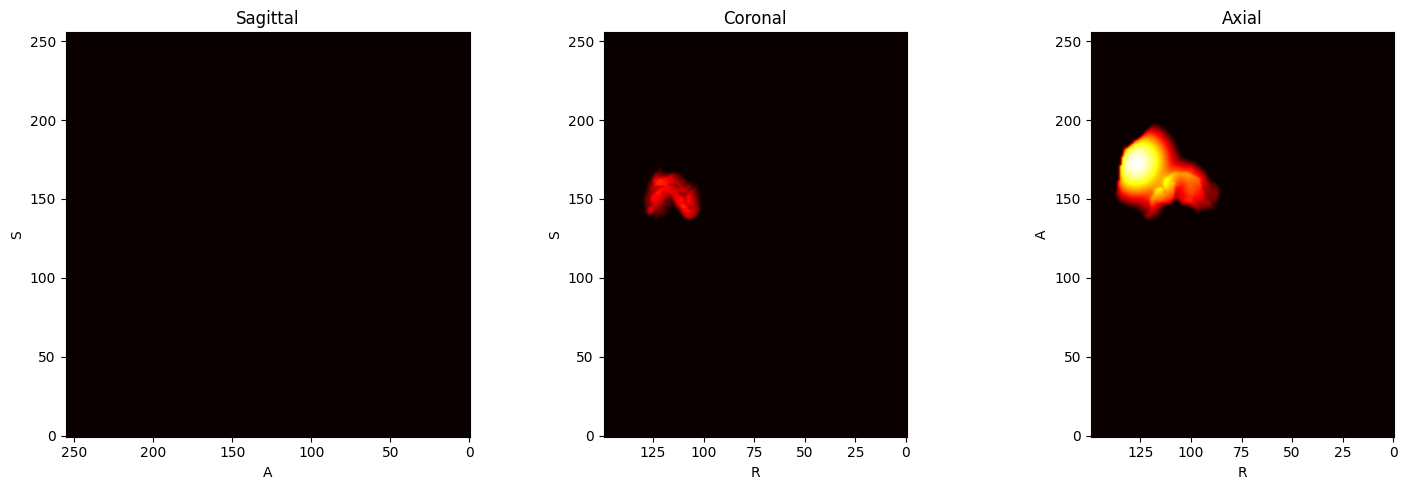

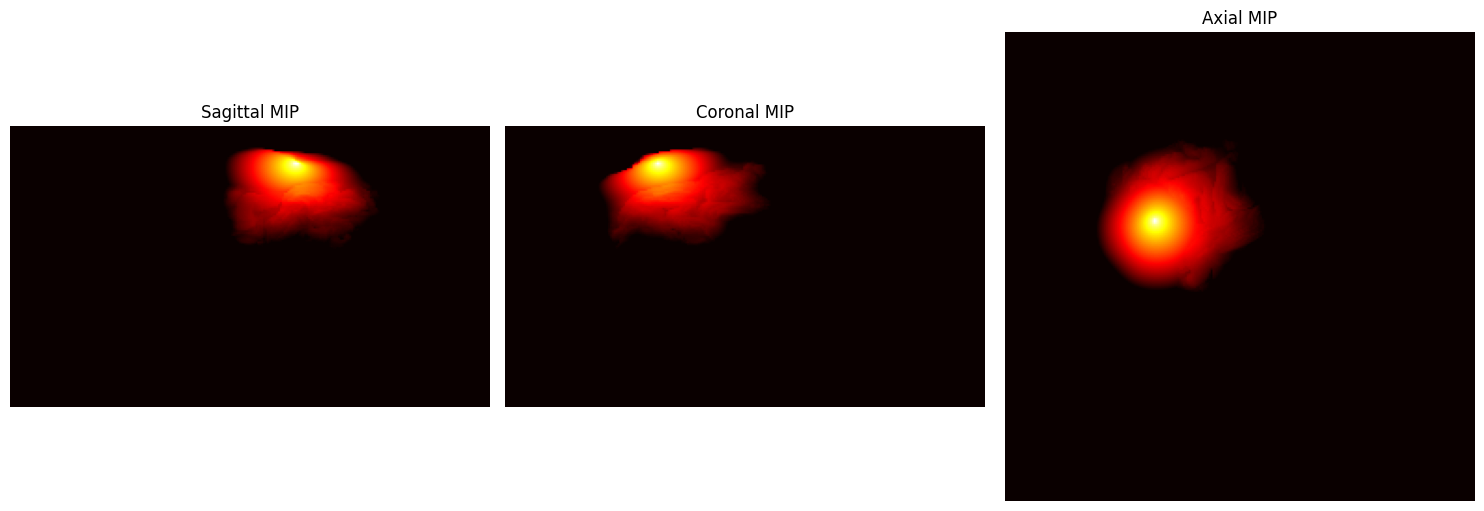

==================== IMAGE STATISTICS ====================
FILE: ../IXI_mcx/m2m_IXI266-Guy/pmcx_output/full/MCX_F8_p250_t8_results_log.nii.gz

[Geometry & Metadata]
  Shape (C, W, H, D): (1, 256, 256, 150)
  Spacing (mm):       (0.9375000000000001, 0.9375, 1.1999982595443726)
  Orientation:        ('P', 'S', 'R')
  Origin:             (-89.95555877685547, 121.483154296875, -127.365966796875)
  Physical Volume:    10367984.96 mm³

[Intensity Distribution]
  Range:              [-10.0000, -1.8677]
  Mean ± Std:         -9.9746 ± 0.2569
  Median:             -10.0000
  IQR (Q1 - Q3):      -10.0000 - -10.0000 (Width: 0.0000)
  Skewness:           12.9261 (Positive = right tail)
  Kurtosis:           194.4441 (High = outliers/heavy tails)

[Data Integrity]
  Total Voxels:       9830400
  Zero Voxels:        0 (0.00%)
  Unique Values:      151108
  Corrupted (NaN/Inf): 0 / 0


In [57]:
log_data = file_dict["image"]
check(log_data)

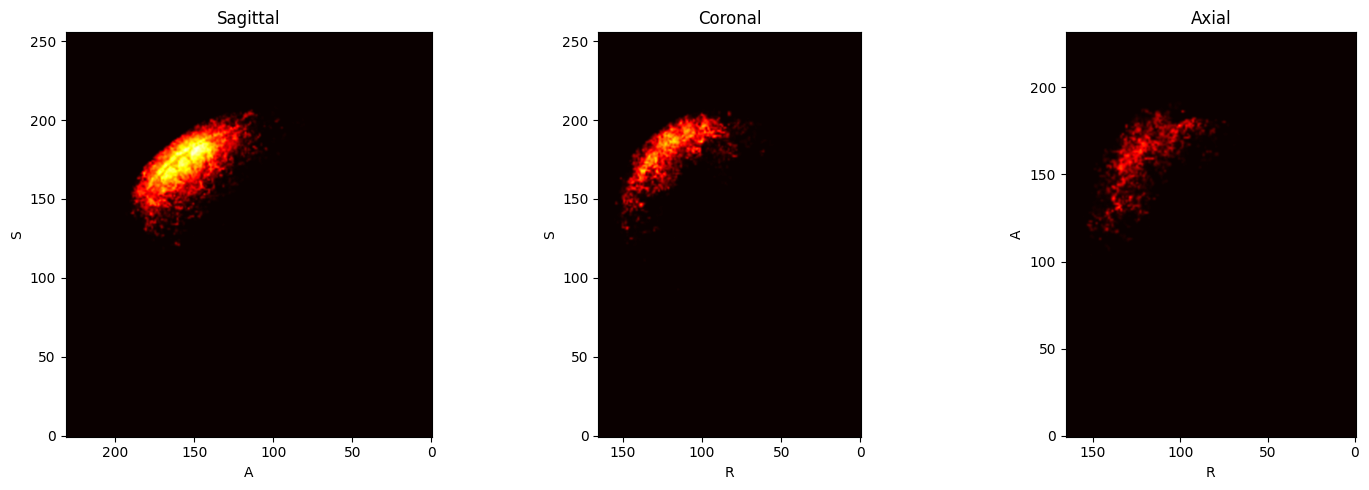

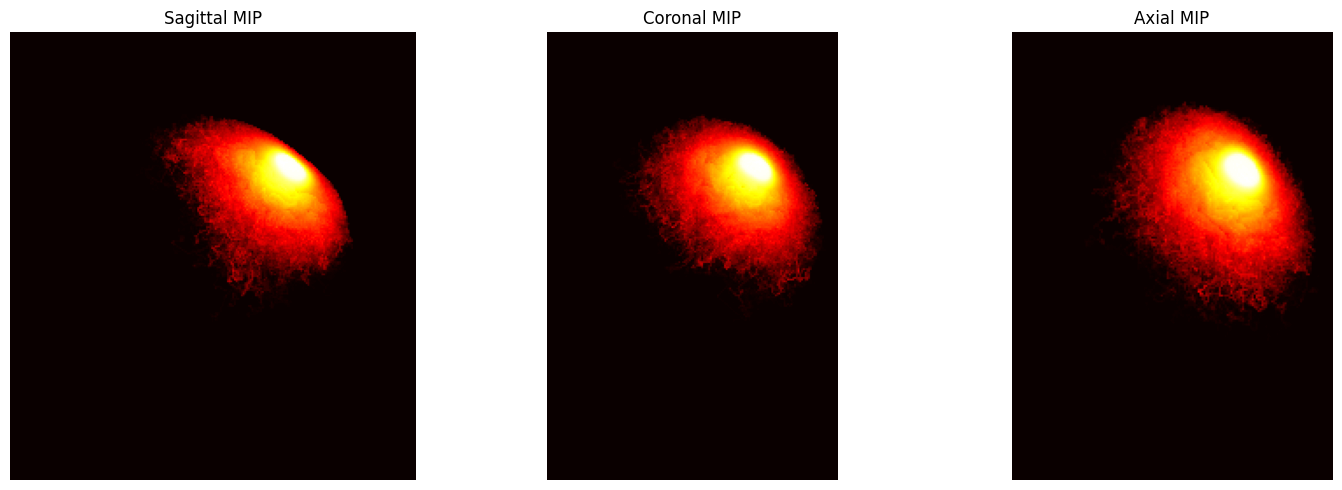

==================== IMAGE STATISTICS ====================
FILE: /data1/syliu/ixi_mcx_2025/temp_sample/feature_fix_inputs/TLS_sub-1_T1w_RAS_1064nm_20260131_2208_raw_log10.nii

[Geometry & Metadata]
  Shape (C, W, H, D): (1, 166, 232, 256)
  Spacing (mm):       (1.0024033784866333, 0.9999999999999999, 1.0)
  Orientation:        ('R', 'A', 'S')
  Origin:             (-82.71762084960938, -112.85340118408203, -127.67472076416016)
  Physical Volume:    9882767.08 mm³

[Intensity Distribution]
  Range:              [-10.0000, -3.6372]
  Mean ± Std:         -9.9610 ± 0.3208
  Median:             -10.0000
  IQR (Q1 - Q3):      -10.0000 - -10.0000 (Width: 0.0000)
  Skewness:           10.3897 (Positive = right tail)
  Kurtosis:           122.6116 (High = outliers/heavy tails)

[Data Integrity]
  Total Voxels:       9859072
  Zero Voxels:        0 (0.00%)
  Unique Values:      277467
  Corrupted (NaN/Inf): 0 / 0


In [58]:
feature_fix_inputs = "/data1/syliu/ixi_mcx_2025/temp_sample/feature_fix_inputs/TLS_sub-1_T1w_RAS_1064nm_20260131_2208_raw.nii"

feature_fix_inputs_log10 = convertRaw2Log10(feature_fix_inputs)

check(feature_fix_inputs_log10)


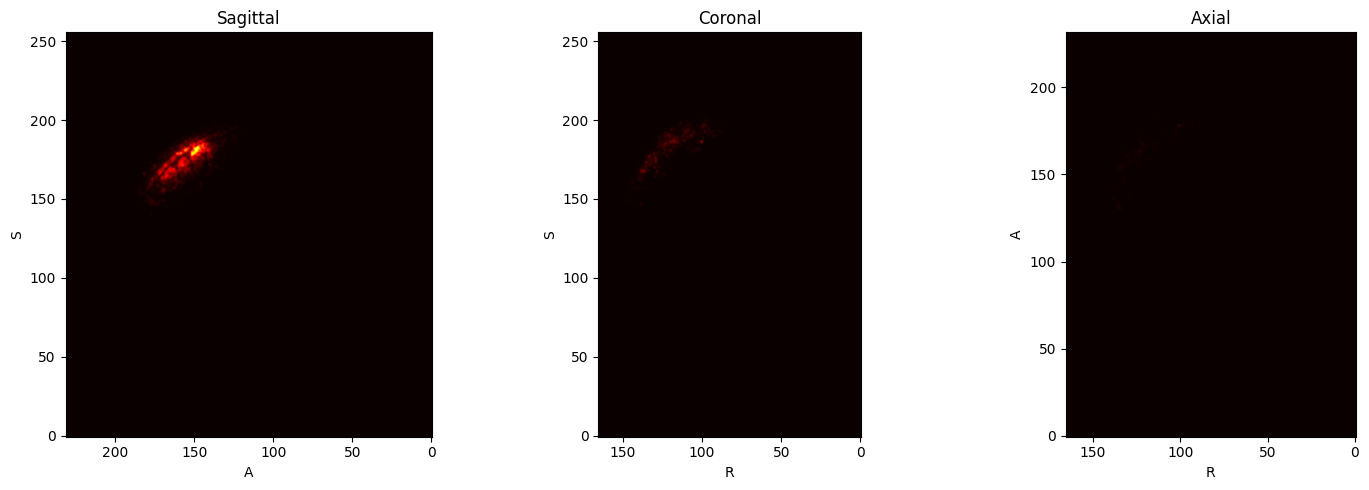

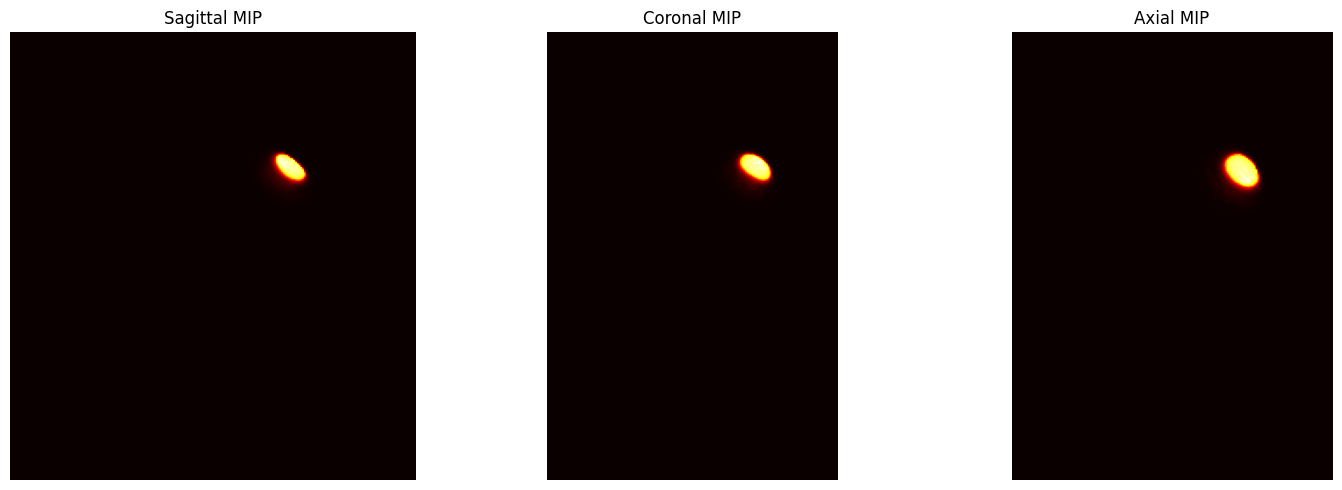

==================== IMAGE STATISTICS ====================
FILE: /data1/syliu/ixi_mcx_2025/temp_sample/feature_fix_inputs/TLS_sub-1_T1w_RAS_1064nm_20260131_2208_raw.nii

[Geometry & Metadata]
  Shape (C, W, H, D): (1, 166, 232, 256)
  Spacing (mm):       (1.0024033784866333, 0.9999999999999999, 1.0)
  Orientation:        ('R', 'A', 'S')
  Origin:             (-82.71762084960938, -112.85340118408203, -127.67472076416016)
  Physical Volume:    9882767.08 mm³

[Intensity Distribution]
  Range:              [0.0000, 0.0002]
  Mean ± Std:         0.0000 ± 0.0000
  Median:             0.0000
  IQR (Q1 - Q3):      0.0000 - 0.0000 (Width: 0.0000)
  Skewness:           94.9142 (Positive = right tail)
  Kurtosis:           10143.1711 (High = outliers/heavy tails)

[Data Integrity]
  Total Voxels:       9859072
  Zero Voxels:        8819319 (89.45%)
  Unique Values:      1036147
  Corrupted (NaN/Inf): 0 / 0


In [47]:
feature_fix_inputs = "/data1/syliu/ixi_mcx_2025/temp_sample/feature_fix_inputs/TLS_sub-1_T1w_RAS_1064nm_20260131_2208_raw.nii"
# feature_fix_inputs
# data = tio.ScalarImage(feature_fix_inputs)
plot(feature_fix_inputs)
plot_mip(feature_fix_inputs)
stat(feature_fix_inputs)

In [ ]:
from pmcx_uitls import direct_mcx_run
x, y, z, vol_data, affine_matrix = load_real_data()

# Test directory
test_dir = "3.pmcx.direct_run.test.files"
os.makedirs(test_dir, exist_ok=True)

# Run direct_mcx_run in simple mode only (disabled full mode)
print("Running direct_mcx_run in simple mode...")
result_simple = direct_mcx_run(
    x, y, z, vol_data, 
    affine_matrix=affine_matrix,
    save_path=os.path.join(test_dir, "results_simple"),
    mode="simple"
)

# Load flux data from simple mode run
flux_simple = result_simple['flux']

'hi'

# Fake codes below 

In [ ]:
from shiyu_utils.maisi_transforms import VAE_Transform
transform = VAE_Transform(
    is_train=False,
    random_aug=False,
    val_patch_size=(160,256,256),
    output_dtype=torch.float32,
    spacing_type="original",
    image_keys=["image"]
)
transform = transform.transform_dict["ct"]
transform.transforms[-3].scaler.a_min=-10
transform.transforms[-3].scaler.a_max=0 
one_real_data = transform(file_dict)
import monai 
from monai.bundle.config_parser import ConfigParser
import torch 
# !mkdir models
# !cp  /data1/syliu/miccai24_maisi_SR/models/autoencoder_epoch273.pt models/autoencoder_epoch273.pt 
config= ConfigParser()
config.read_config("shiyu_utils/config_maisi3d-rflow.json")
autoencoder = config.get_parsed_content("autoencoder_def")
autoencoder.load_state_dict(torch.load("models/autoencoder_epoch273.pt"))
autoencoder=autoencoder.eval().cuda()
for k,v in one_real_data.items():
    print(k,v.shape)
with torch.no_grad(),torch.cuda.amp.autocast(True):
    one_real_latent ={}
    for k,v in one_real_data.items():
        one_real_latent[k] = autoencoder.encode_stage_2_inputs(v[None,...].cuda().float())
        one_real_latent[k] *= 0.25
    for k,v in one_real_latent.items():
        print(k,v.shape)


# step 1 : process data from somewhere , a loader, a ground truth path 
# pre-process from .nii space to latent .pt space 
from copy import deepcopy
data = deepcopy(one_real_latent)
input,output,_ = trainer._process_input(data)
#output = trainer.sample(fname="temp.png")

# step 2 : get generation result in .nii space  
output_dict  = sample_from_trainer(trainer,input,output,None)

# step 3 : get evaluation in SSIM,PSNR,MAE,MSE,mip visualization and others so on. 
# optional : use seg . 
output_dict["target"]=one_real_data["source_image"][None,...].cuda().float()
assert "input" in output_dict.keys()
if "gen" in output_dict.keys() and "target" in output_dict.keys():
    metric_value = return_metric_value(output_dict["gen"],output_dict["target"])
    for k,v in metric_value.items():
        print(k,v)

diff = output_dict["gen"]-output_dict["target"]
max_diff = np.percentile(diff.float().detach().cpu().numpy(),99)
min_diff = np.percentile(diff.float().detach().cpu().numpy(),1)
print("max_diff(org range in [0,1]):",max_diff)
print("min_diff(org range in [0,1]):",min_diff)

# For generated/target images
plot_mip(output_dict["gen"], cmap_main="magma", vmin_main=0, vmax_main=1)
plot_mip(output_dict["target"], cmap_main="magma", vmin_main=0, vmax_main=1)
plot_mip(output_dict["input"], cmap_main="magma", vmin_main=0, vmax_main=1)

# For the absolute difference
plot_mip(diff.abs(), cmap_main="hot", vmin_main=0, vmax_main=1)

output_dict["gen"]=(10*output_dict["gen"]).exp()-1 
output_dict["target"]=(10*output_dict["target"]).exp()-1
output_dict["input"]=(10*output_dict["input"]).exp()-1
diff = output_dict["gen"]-output_dict["target"]
max_diff = np.percentile(diff.float().detach().cpu().numpy(),99)
min_diff = np.percentile(diff.float().detach().cpu().numpy(),1)
print("max_diff(org range in [0,1]):",max_diff)
print("min_diff(org range in [0,1]):",min_diff)

# For generated/target images
plot_mip(output_dict["gen"], cmap_main="magma", vmin_main=0, vmax_main=1)
plot_mip(output_dict["target"], cmap_main="magma", vmin_main=0, vmax_main=1)
plot_mip(output_dict["input"], cmap_main="magma", vmin_main=0, vmax_main=1)

# For the absolute difference
plot_mip(diff.abs(), cmap_main="hot", vmin_main=0, vmax_main=1)